In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
df_raw = pd.read_csv(r"D:\Advertising.csv")

In [3]:
df_raw.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df_raw.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [6]:
df_raw.isna().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [7]:
df_raw.duplicated().sum()

np.int64(0)

In [8]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [14]:
df_raw.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [15]:
df = df_raw.copy()
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [16]:
df = df.drop(columns=['Unnamed: 0'],axis=1)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [17]:
df.describe().style.background_gradient(cmap='viridis')

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


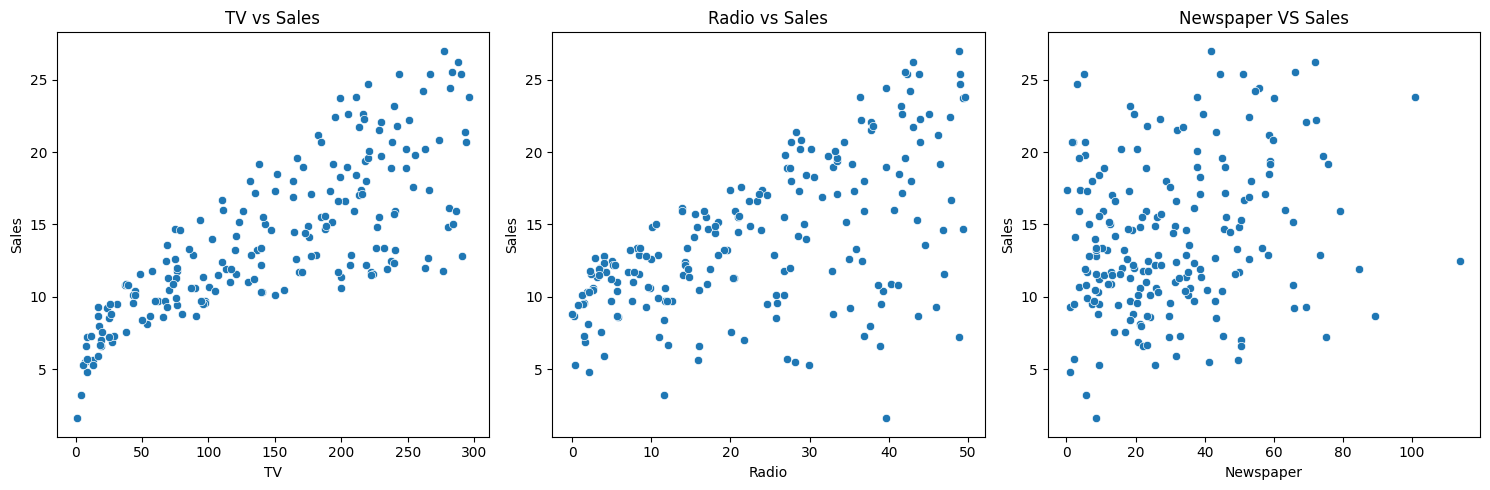

In [18]:
fig,axes = plt.subplots(1 ,3 ,figsize=(15,5))

# plot TV vs sales
sns.scatterplot(data=df ,x='TV',y='Sales',ax=axes[0])
axes[0].set_title('TV vs Sales')

# plot Radio vs Sales
sns.scatterplot(data=df,x='Radio',y='Sales',ax=axes[1])
axes[1].set_title('Radio vs Sales')

# plot NewsPaper vs Sales
sns.scatterplot(data=df,x='Newspaper',y='Sales',ax=axes[2])
axes[2].set_title('Newspaper VS Sales')

plt.tight_layout()
plt.show()

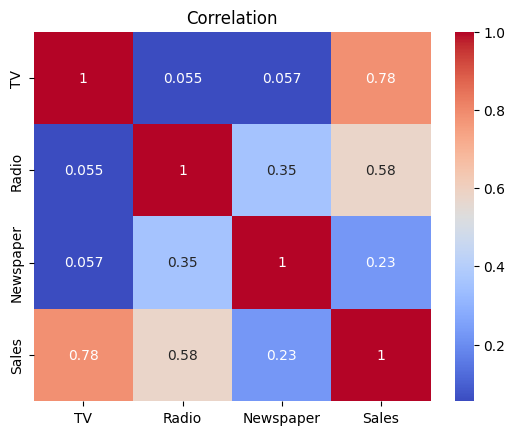

In [19]:
correlation = df.corr()

sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Correlation')
plt.show()

TV = 0.78 → Sales ke saath strong positive relationship hai.
Radio = 0.58 → Sales ke saath moderate positive relationship hai.
Newspaper = 0.23 → Sales ke saath weak positive relationship hai.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics 

In [21]:
x = df[['TV','Radio','Newspaper']]
y = df['Sales']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

x_train.shape,x_test.shape

((160, 3), (40, 3))

In [23]:
lr = LinearRegression()

lr.fit(x_train,y_train)

coeff_df = pd.DataFrame(lr.coef_,x.columns,columns=['Coefficient'])
print(coeff_df)

           Coefficient
TV            0.044730
Radio         0.189195
Newspaper     0.002761


In [24]:
y_yred = lr.predict(x_test)

mae = metrics.mean_absolute_error(y_test,y_yred)
rmse =np.sqrt(metrics.root_mean_squared_error(y_test,y_yred))
r2 =  metrics.r2_score(y_test,y_yred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Absolute Error (MAE): 1.46
Root Mean Squared Error (RMSE): 1.33
R-squared Score: 0.90


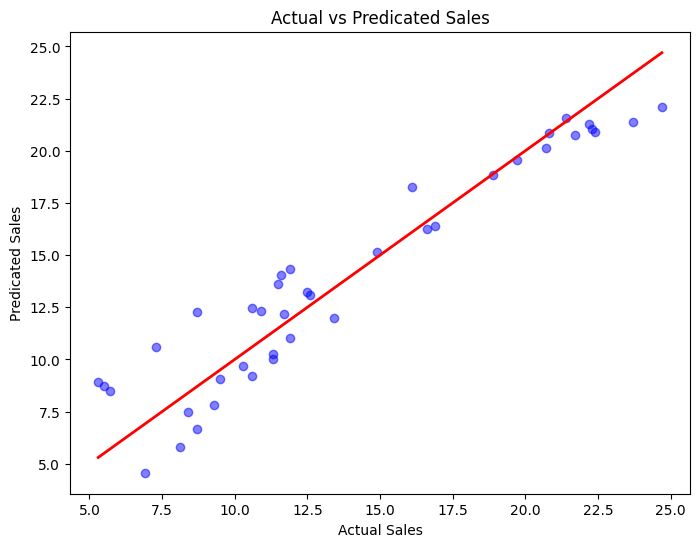

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_yred,color='blue',alpha=0.5)
plt.plot([y_test.min(),y_test.max()],[y_test.min(), y_test.max()],color='red',lw=2)

plt.xlabel('Actual Sales')
plt.ylabel('Predicated Sales')
plt.title('Actual vs Predicated Sales')
plt.show()


In [28]:
print(lr.intercept_)

2.979067338122629


In [29]:
x_final = df[['TV','Radio']]
y = df['Sales']

x_train,x_test,y_train,y_test = train_test_split(x_final,y,test_size=0.2,random_state=42)

final_lr = LinearRegression()
final_lr.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
new_budget = pd.DataFrame({'TV':[200], 'Radio':[30]})
predicted_sales = final_lr.predict(new_budget)

print(f'Predicated sales: {predicted_sales[0]:.2f} units')

Predicated sales: 17.69 units


In [ ]:
df.columns = [str.strip(c) for c in df.columns]

# remove common  csv index columns
index_like = [c for c in df.columns if c.lower().startswith("unnamed")]
if index_like:
    df = df.drop(columns=index_like)

required_cols = ["TV","Radio","Newspaper","Sales"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Required columns are missing: {missing_required}")


for col in required_cols:
    df[col] = pd.to_numeric(df[col],errors="coerce")

audit = pd.DataFrame({
    "Data Types": df.dtypes.astype(str),
    "Missing Values":df.isna().sum(),
    "Unique Values":df.nunique(),
    "Minimum":df.min(numeric_only=True),
    "Maximum":df.max(numeric_only=True)
})

display(audit)

print("Duplicate row before cleaning:",df.duplicated().sum())
print("Row with missing values before cleaning:",df.isna().any(axis=1).sum())

,Data Types,Missing Values,Unique Values,Minimum,Maximum
TV,float64,0,190,0.7,296.4
Radio,float64,0,167,0.0,49.6
Newspaper,float64,0,172,0.3,114.0
Sales,float64,0,121,1.6,27.0


Duplicate row before cleaning: 0
Row with missing values before cleaning: 0


In [12]:
before_rows = len(df)
duplicate_count = int(df.duplicated().sum())

df.drop_duplicates().dropna(subset=required_cols).reset_index(drop=True)

negative_counts = (df[["TV","Radio", "Newspaper"]] < 0).sum()
negative_rows = int((df[["TV","Radio", "Newspaper"]] < 0).any(axis=1).sum())

if negative_rows > 0:
    df = df[(df[["TV","Radio", "Newspaper"]] >= 0 ).all(axis=1)].reset_index(drop=True)  